In [1]:
import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
from GmGM import GmGM
from gprofiler import GProfiler
import warnings
import os
import shutil
from utilities import plot_graph
import matplotlib.pyplot as plt
from scipy import sparse, io, stats
import warnings
from pybiomart import Dataset
from sklearn import metrics
import matplotlib.transforms as transforms
from matplotlib.patches import Patch
from balanced_clustering import balanced_adjusted_mutual_info, balanced_homogeneity, balanced_completeness
import igraph as ig

In [2]:
all_pathways = pd.read_csv("./results/gmgm_pathway/gmgm/gene_pathways.csv")
all_pathways_no_lnc = pd.read_csv("./results/gmgm_pathway/gmgm/gene_pathways_no_lnc.csv")
all_pathways

,Unnamed: 0,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
0,0,GO:CC,GO:0005929,cilium,1.361878e-142,True,"""A specialized eukaryotic organelle that consi...",732,589,180,28662,0.305603,0.245902,Cluster 2,"['GO:0043227', 'GO:0120025']"
1,1,REAC,REAC:R-HSA-156902,Peptide chain elongation,6.355346e-123,True,Peptide chain elongation,87,299,70,28662,0.234114,0.804598,Cluster 7,['REAC:R-HSA-156842']
2,2,REAC,REAC:R-HSA-156842,Eukaryotic Translation Elongation,6.569360e-123,True,Eukaryotic Translation Elongation,91,299,71,28662,0.237458,0.780220,Cluster 7,['REAC:R-HSA-72766']
3,3,GO:MF,GO:0030527,structural constituent of chromatin,1.366046e-121,True,"""The action of a molecule that contributes to ...",77,93,54,28662,0.580645,0.701299,Cluster 105,['GO:0005198']
4,4,REAC,REAC:R-HSA-192823,Viral mRNA Translation,1.357761e-117,True,Viral mRNA Translation,87,299,68,28662,0.227425,0.781609,Cluster 7,['REAC:R-HSA-168273']
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36097,36097,CORUM,CORUM:895,"hMediator complex (MED23, CDK8, CCNC, MED7)",4.999349e-02,True,"hMediator complex (MED23, CDK8, CCNC, MED7)",3,172,2,28662,0.011628,0.666667,Cluster 29,['CORUM:0000000']
36098,36098,HP,HP:0010459,True hermaphroditism,4.999696e-02,True,The presence of both ovarian and testicular ti...,19,589,5,28662,0.008489,0.263158,Cluster 2,['HP:0000062']
36099,36099,HPA,HPA:0320000,Nasopharynx,4.999907e-02,True,Nasopharynx,7008,148,56,28662,0.378378,0.007991,Cluster 58,['HPA:0000000']
36100,36100,CORUM,CORUM:2086,NFKB1-NFKB2-RELA-RELB complex,4.999923e-02,True,NFKB1-NFKB2-RELA-RELB complex,3,145,2,28662,0.013793,0.666667,Cluster 60,['CORUM:0000000']


In [3]:
for key, value in all_pathways_no_lnc.loc[all_pathways_no_lnc["source"].isin(["GO:BP"]), "name"].value_counts().items():
    if value > 5:
        print(f"{key}: {value}")

biological_process: 119
cellular process: 119
metabolic process: 101
biological regulation: 93
primary metabolic process: 93
regulation of cellular process: 90
regulation of biological process: 87
macromolecule metabolic process: 81
biosynthetic process: 61
gene expression: 50
macromolecule biosynthetic process: 50
regulation of metabolic process: 46
cellular component organization or biogenesis: 45
nucleobase-containing compound metabolic process: 44
cellular component organization: 43
nucleic acid metabolic process: 38
regulation of macromolecule metabolic process: 38
regulation of primary metabolic process: 37
positive regulation of biological process: 37
response to stimulus: 36
protein metabolic process: 33
positive regulation of cellular process: 33
nucleobase-containing compound biosynthetic process: 32
RNA metabolic process: 31
nucleic acid biosynthetic process: 31
RNA biosynthetic process: 30
regulation of biosynthetic process: 30
cellular response to stimulus: 29
negative reg

In [4]:
moran_csv = pd.read_csv("results/gmgm_pathway/gmgm/all_gene_module_homogeneities.csv")
moran_csv.index = moran_csv["module"]
moran_csv

,module,morans_i_mean,morans_i_percent
module,,,
m1,m1,1.091330,1.067051
m6,m6,0.953299,0.942078
m90,m90,0.928805,0.934504
m11,m11,0.925225,0.897286
m9,m9,0.871511,0.888429
...,...,...,...
m55,m55,0.504384,0.040557
m15,m15,0.515308,0.039587
m77,m77,0.360977,0.038501


In [5]:
# Get all the Moran's I score per module
moran_csv["module_names"] = moran_csv.index.str.slice(start=1).astype(int)
for idx, val in moran_csv.sort_values(by="module_names")[["module_names", "morans_i_percent"]].iterrows():
    print(f"m{int(val.values[0])}, {val.values[1]:.2f}")

m0, 0.15
m1, 1.07
m2, 0.82
m3, 0.83
m4, 0.71
m5, 0.82
m6, 0.94
m7, 0.77
m8, 0.58
m9, 0.89
m10, 0.57
m11, 0.90
m12, 0.66
m13, 0.70
m14, 0.76
m15, 0.04
m16, 0.74
m17, 0.39
m18, 0.08
m19, 0.40
m20, 0.42
m21, 0.06
m22, 0.11
m23, 0.64
m24, 0.53
m25, 0.85
m26, 0.18
m27, 0.76
m28, 0.23
m29, 0.12
m30, 0.86
m31, 0.07
m32, 0.08
m33, 0.08
m34, 0.07
m35, 0.05
m36, 0.05
m37, 0.10
m38, 0.06
m39, 0.06
m40, 0.07
m41, 0.16
m42, 0.48
m43, 0.13
m44, 0.09
m45, 0.10
m46, 0.08
m47, 0.05
m48, 0.14
m49, 0.11
m50, 0.61
m51, 0.76
m52, 0.05
m53, 0.07
m54, 0.08
m55, 0.04
m56, 0.16
m57, 0.12
m58, 0.04
m59, 0.05
m60, 0.18
m61, 0.05
m62, 0.80
m63, 0.34
m64, 0.06
m65, 0.09
m66, 0.07
m67, 0.10
m68, 0.16
m69, 0.12
m70, 0.16
m71, 0.26
m72, 0.08
m73, 0.17
m74, 0.05
m75, 0.09
m76, 0.03
m77, 0.04
m78, 0.09
m79, 0.09
m80, 0.10
m81, 0.07
m82, 0.07
m83, 0.04
m84, 0.33
m85, 0.06
m86, 0.08
m87, 0.09
m88, 0.06
m89, 0.06
m90, 0.93
m91, 0.85
m92, 0.05
m93, 0.16
m94, 0.11
m95, 0.18
m96, 0.07
m97, 0.07
m98, 0.10
m99, 0.04
m100, 0.68

In [6]:
lnc_csv = pd.read_csv("results/gmgm_pathway/gmgm/lnc_percentage_per_module.csv")
lnc_csv.index = lnc_csv["module"]
lnc_csv

,module,lnc_percentage
module,,
m0,m0,0.543053
m14,m14,0.372642
m20,m20,0.343434
m6,m6,0.338658
m42,m42,0.329268
...,...,...
m26,m26,0.124294
m7,m7,0.112211
m5,m5,0.104762


In [7]:
chrome_csv = pd.read_csv("results/gmgm_pathway/gmgm/all_gene_module_chromosome_overexpression.csv")
chrome_csv.index = "m" + chrome_csv["module"].astype(str)
chrome_csv

,module,max_chromosome_overexpression,most_overexpressed_chromosome
module,,,
m117,117,248.891975,MT
m75,75,11.891322,Y
m103,103,10.860741,MT
m105,105,9.706523,6
m32,32,9.526966,Y
...,...,...,...
m43,43,1.522442,20
m10,10,1.488347,8
m47,47,1.474776,3


In [8]:
adata = ad.read_h5ad("results/gmgm_pathway/anndata.h5ad")
adata.var["ID"] = adata.var_names
adata

AnnData object with n_obs × n_vars = 6876 × 29324
    obs: 'source', 'm114_mean', 'm114_percent', 'm37_mean', 'm37_percent', 'm95_mean', 'm95_percent', 'm54_mean', 'm54_percent', 'm12_mean', 'm12_percent', 'm93_mean', 'm93_percent', 'm4_mean', 'm4_percent', 'm15_mean', 'm15_percent', 'm52_mean', 'm52_percent', 'm22_mean', 'm22_percent', 'm57_mean', 'm57_percent', 'm17_mean', 'm17_percent', 'm101_mean', 'm101_percent', 'm70_mean', 'm70_percent', 'm48_mean', 'm48_percent', 'm6_mean', 'm6_percent', 'm79_mean', 'm79_percent', 'm50_mean', 'm50_percent', 'm38_mean', 'm38_percent', 'm108_mean', 'm108_percent', 'm47_mean', 'm47_percent', 'm40_mean', 'm40_percent', 'm82_mean', 'm82_percent', 'm92_mean', 'm92_percent', 'm74_mean', 'm74_percent', 'm3_mean', 'm3_percent', 'm58_mean', 'm58_percent', 'm111_mean', 'm111_percent', 'm89_mean', 'm89_percent', 'm0_mean', 'm0_percent', 'm1_mean', 'm1_percent', 'm30_mean', 'm30_percent', 'm10_mean', 'm10_percent', 'm23_mean', 'm23_percent', 'm44_mean', 'm4

In [9]:
clusters = adata.var["leiden_gmgm"].unique()
clusters

['114', '37', '95', '54', '12', ..., '96', '33', '118', '71', '102']
Length: 119
Categories (119, object): ['0', '1', '2', '3', ..., '115', '116', '117', '118']

In [10]:
shortlist = {}
for cluster in clusters:
    module = f"m{cluster}"
    attributes = set({})
    # Check if it has a high moran's i
    if moran_csv.loc[module, "morans_i_percent"] > 0.5:
        attributes.add("High Moran's I")
    if lnc_csv.loc[module, "lnc_percentage"] > 0.3:
        attributes.add("High LNC %")
    if lnc_csv.loc[module, "lnc_percentage"] < 0.15:
        attributes.add("Low LNC %")
    if chrome_csv.loc[module, "max_chromosome_overexpression"] > 3.0:
        attributes.add(f"High chromosome {chrome_csv.loc[module, 'most_overexpressed_chromosome']} focus")
        attributes.add(f"High chromosome focus")
    query = f"Cluster {cluster}"
    local_pathways = all_pathways.loc[
        (all_pathways["query"] == query) & all_pathways.source.isin(["GO:BP", "GO:MF", "GO:CC", "KEGG"]),
        "native"
    ]
    local_pathways_no_lnc = all_pathways_no_lnc.loc[
        (all_pathways_no_lnc["query"] == query) & all_pathways_no_lnc.source.isin(["GO:BP", "GO:MF", "GO:CC", "KEGG"]),
        "native"
    ]
    if "GO:0022008" in local_pathways.values:
        attributes.add("Neurogenesis")
    if "GO:0022008" in local_pathways_no_lnc.values:
        attributes.add("Neurogenesis (w/o LNCs)")
    if "GO:0007420" in local_pathways.values:
        attributes.add("Brain development")
    if "GO:0007420" in local_pathways_no_lnc.values:
        attributes.add("Brain development (w/o LNCs)")
    if "GO:0048666" in local_pathways.values:
        attributes.add("Neuron development")
    if "GO:0048666" in local_pathways_no_lnc.values:
        attributes.add("Neuron development (w/o LNCs)")
    if "GO:0007417" in local_pathways.values:
        attributes.add("Central nervous system development")
    if "GO:0007417" in local_pathways_no_lnc.values:
        attributes.add("Central nervous system development (w/o LNCs)")
    if "GO:0030900" in local_pathways.values:
        attributes.add("Forebrain development")
    if "GO:0030900" in local_pathways_no_lnc.values:
        attributes.add("Forebrain development (w/o LNCs)")
    if "GO:0030855" in local_pathways.values:
        attributes.add("Epithelial cell differentiation")
    if "GO:0030855" in local_pathways_no_lnc.values:
        attributes.add("Epithelial cell differentiation (w/o LNCs)")
    if "GO:0060537" in local_pathways.values:
        attributes.add("Muscle tissue development")
    if "GO:0060537" in local_pathways_no_lnc.values:
        attributes.add("Muscle tissue development (w/o LNCs)")
    if "GO:0006396" in local_pathways.values:
        attributes.add("RNA processing")
    if "GO:0006396" in local_pathways_no_lnc.values:
        attributes.add("RNA processing (w/o LNCs)")
    if "GO:0022402" in local_pathways.values:
        attributes.add("Cell cycle process")
    if "GO:0022402" in local_pathways_no_lnc.values:
        attributes.add("Cell cycle process (w/o LNCs)")
    if "GO:0048667" in local_pathways.values:
        attributes.add("Cell morphogenesis involved in neuron differentiation")
    if "GO:0048667" in local_pathways_no_lnc.values:
        attributes.add("Cell morphogenesis involved in neuron differentiation (w/o LNCs)")
    if "GO:0012501" in local_pathways.values:
        attributes.add("Programmed cell death")
    if "GO:0012501" in local_pathways_no_lnc.values:
        attributes.add("Programmed cell death (w/o LNCs)")
    if "GO:0051093" in local_pathways.values:
        attributes.add("Negative regulation of developmental process")
    if "GO:0051093" in local_pathways_no_lnc.values:
        attributes.add("Negative regulation of developmental process (w/o LNCs)")
    if "GO:0051094" in local_pathways.values:
        attributes.add("Positive regulation of developmental process")
    if "GO:0051094" in local_pathways_no_lnc.values:
        attributes.add("Positive regulation of developmental process (w/o LNCs)")
    if "GO:0006260" in local_pathways.values:
        attributes.add("DNA replication")
    if "GO:0006260" in local_pathways_no_lnc.values:
        attributes.add("DNA replication (w/o LNCs)")
    if "KEGG:01100" in local_pathways.values:
        attributes.add("[KEGG] Metabolic pathways")
    if "KEGG:01100" in local_pathways_no_lnc.values:
        attributes.add("[KEGG] Metabolic pathways (w/o LNCs)")
    if "KEGG:00100" in local_pathways.values:
        attributes.add("[KEGG] Steroid biosynthesis")
    if "KEGG:00100" in local_pathways_no_lnc.values:
        attributes.add("[KEGG] Steroid biosynthesis (w/o LNCs)")
    if "KEGG:04152" in local_pathways.values:
        attributes.add("[KEGG] AMPK signaling pathway")
    if "KEGG:04152" in local_pathways_no_lnc.values:
        attributes.add("[KEGG] AMPK signaling pathway (w/o LNCs)")
    if "KEGG:04912" in local_pathways.values:
        attributes.add("[KEGG] GnRH signaling pathway")
    if "KEGG:04912" in local_pathways_no_lnc.values:
        attributes.add("[KEGG] GnRH signaling pathway (w/o LNCs)")
    shortlist[module] = attributes

shortlist

{'m114': {'Low LNC %'},
 'm37': {'[KEGG] AMPK signaling pathway',
  '[KEGG] AMPK signaling pathway (w/o LNCs)'},
 'm95': set(),
 'm54': set(),
 'm12': {'Cell cycle process',
  'Cell cycle process (w/o LNCs)',
  'DNA replication',
  'DNA replication (w/o LNCs)',
  "High Moran's I",
  'Low LNC %'},
 'm93': {'Low LNC %'},
 'm4': {"High Moran's I",
  'Muscle tissue development (w/o LNCs)',
  'Negative regulation of developmental process (w/o LNCs)',
  'Neurogenesis',
  'Neurogenesis (w/o LNCs)',
  'Neuron development (w/o LNCs)',
  'Positive regulation of developmental process',
  'Positive regulation of developmental process (w/o LNCs)',
  'Programmed cell death',
  'Programmed cell death (w/o LNCs)'},
 'm15': {'High chromosome MT focus', 'High chromosome focus'},
 'm52': set(),
 'm22': set(),
 'm57': set(),
 'm17': set(),
 'm101': set(),
 'm70': set(),
 'm48': set(),
 'm6': {'High LNC %',
  "High Moran's I",
  'Neurogenesis (w/o LNCs)',
  'Positive regulation of developmental process (w/

In [11]:
# Interesting clusters
interesting_shortlist = {
    key: value
    for key, value
    in shortlist.items()
    if len(value) > 0
}
interesting_shortlist

{'m114': {'Low LNC %'},
 'm37': {'[KEGG] AMPK signaling pathway',
  '[KEGG] AMPK signaling pathway (w/o LNCs)'},
 'm12': {'Cell cycle process',
  'Cell cycle process (w/o LNCs)',
  'DNA replication',
  'DNA replication (w/o LNCs)',
  "High Moran's I",
  'Low LNC %'},
 'm93': {'Low LNC %'},
 'm4': {"High Moran's I",
  'Muscle tissue development (w/o LNCs)',
  'Negative regulation of developmental process (w/o LNCs)',
  'Neurogenesis',
  'Neurogenesis (w/o LNCs)',
  'Neuron development (w/o LNCs)',
  'Positive regulation of developmental process',
  'Positive regulation of developmental process (w/o LNCs)',
  'Programmed cell death',
  'Programmed cell death (w/o LNCs)'},
 'm15': {'High chromosome MT focus', 'High chromosome focus'},
 'm6': {'High LNC %',
  "High Moran's I",
  'Neurogenesis (w/o LNCs)',
  'Positive regulation of developmental process (w/o LNCs)',
  'Programmed cell death (w/o LNCs)'},
 'm79': {'High chromosome MT focus', 'High chromosome focus'},
 'm50': {"High Moran's I

# Load hdWGCNA network

In [12]:
hdWGCNA_network = io.mmread("./results/gmgm_pathway/hdWGCNA_network.mtx").tocsc()
hdWGCNA_names = pd.read_csv("./results/gmgm_pathway/hdWGCNA_genenames.csv")
hdWGCNA_names["name"] = hdWGCNA_names["x"]
hdWGCNA_names = hdWGCNA_names.drop("x", axis=1)
hdWGCNA_names

,name
0,ENSG00000000003
1,ENSG00000000419
2,ENSG00000000457
3,ENSG00000000460
4,ENSG00000001036
...,...
14914,ENSG00000291237
14915,ENSG00000291272
14916,ENSG00000291283
14917,ENSG00000291299


In [13]:
# m8 special gene connected to SHISA9
ensg_connecs_ENSG00000262801 = hdWGCNA_names[
    (hdWGCNA_network[hdWGCNA_names["name"] == "ENSG00000262801", :] != 0).toarray().flatten()
]
print(adata.var["chromosome_name"][adata.var_names == "ENSG00000262801"])
adata.var[["external_gene_name", "chromosome_name"]][adata.var_names.isin(ensg_connecs_ENSG00000262801["name"])]

 
ENSG00000262801    16
Name: chromosome_name, dtype: category
Categories (26, object): ['1', '2', '3', '4', ..., 'MT', 'X', 'Y', 'unknown_chromosome']


,external_gene_name,chromosome_name
,,
ENSG00000231698,ENSG00000231698,11
ENSG00000240563,L1TD1,1
ENSG00000249152,LNCPRESS2,4
ENSG00000254934,LINC00678,11
ENSG00000265992,ESRG,3


In [14]:
# m13 special gene connected to ELAVL2
ensg_connecs_ENSG00000283982 = hdWGCNA_names[
    (hdWGCNA_network[hdWGCNA_names["name"] == "ENSG00000283982", :] != 0).toarray().flatten()
]
print(adata.var["chromosome_name"][adata.var_names == "ENSG00000283982"])
adata.var[["external_gene_name", "chromosome_name"]][adata.var_names.isin(ensg_connecs_ENSG00000283982["name"])]

 
ENSG00000283982    9
Name: chromosome_name, dtype: category
Categories (26, object): ['1', '2', '3', '4', ..., 'MT', 'X', 'Y', 'unknown_chromosome']


,external_gene_name,chromosome_name
,,
ENSG00000104413,ESRP1,8
ENSG00000249152,LNCPRESS2,4
ENSG00000254934,LINC00678,11
ENSG00000258649,ENSG00000258649,14
ENSG00000260834,ENSG00000260834,16


In [15]:
# m90 special gene ENSG00000243620 connected to ZIC
ensg_connecs_ENSG00000243620 = hdWGCNA_names[
    (hdWGCNA_network[hdWGCNA_names["name"] == "ENSG00000243620", :] != 0).toarray().flatten()
]
print(adata.var["chromosome_name"][adata.var_names == "ENSG00000243620"])
adata.var[["external_gene_name", "chromosome_name"]][adata.var_names.isin(ensg_connecs_ENSG00000243620["name"])]

 
ENSG00000243620    3
Name: chromosome_name, dtype: category
Categories (26, object): ['1', '2', '3', '4', ..., 'MT', 'X', 'Y', 'unknown_chromosome']


,external_gene_name,chromosome_name
,,
ENSG00000132669,RIN2,20
ENSG00000133640,LRRIQ1,12
ENSG00000145934,TENM2,5
ENSG00000152977,ZIC1,3
ENSG00000215386,MIR99AHG,21


In [16]:
# m90 special gene ENSG00000286757 connected to ZIC
ensg_connecs_ENSG00000286757 = hdWGCNA_names[
    (hdWGCNA_network[hdWGCNA_names["name"] == "ENSG00000286757", :] != 0).toarray().flatten()
]
print(adata.var["chromosome_name"][adata.var_names == "ENSG00000286757"])
adata.var[["external_gene_name", "chromosome_name"]][adata.var_names.isin(ensg_connecs_ENSG00000286757["name"])]

 
ENSG00000286757    13
Name: chromosome_name, dtype: category
Categories (26, object): ['1', '2', '3', '4', ..., 'MT', 'X', 'Y', 'unknown_chromosome']


,external_gene_name,chromosome_name
,,
ENSG00000133640,LRRIQ1,12
ENSG00000145934,TENM2,5
ENSG00000152977,ZIC1,3
ENSG00000215386,MIR99AHG,21
ENSG00000276644,DACH1,13


## Get Moran's I for each cluster

In [17]:
hdWGCNA_modules = pd.read_csv("results/gmgm_pathway/hdWGCNA_modules.csv").drop("Unnamed: 0", axis=1).drop("color", axis=1)
adata.var["hdWGCNA_module"] = "unassigned"
adata.var.loc[hdWGCNA_modules["gene_name"].values, "hdWGCNA_module"] = hdWGCNA_modules["module"].values
adata.var["hdWGCNA_module"].value_counts()

hdWGCNA_module
unassigned    14405
grey           6399
turquoise      6146
blue            903
brown           559
yellow          409
green           262
red             241
Name: count, dtype: int64

In [18]:
# Get the percentage expression of each module
for value in adata.var['hdWGCNA_module'].unique():
    adata.obs[f'{value}_percent'] = adata.X[:, adata.var["hdWGCNA_module"] == value].sum(axis=1) / adata.X.sum(axis=1)

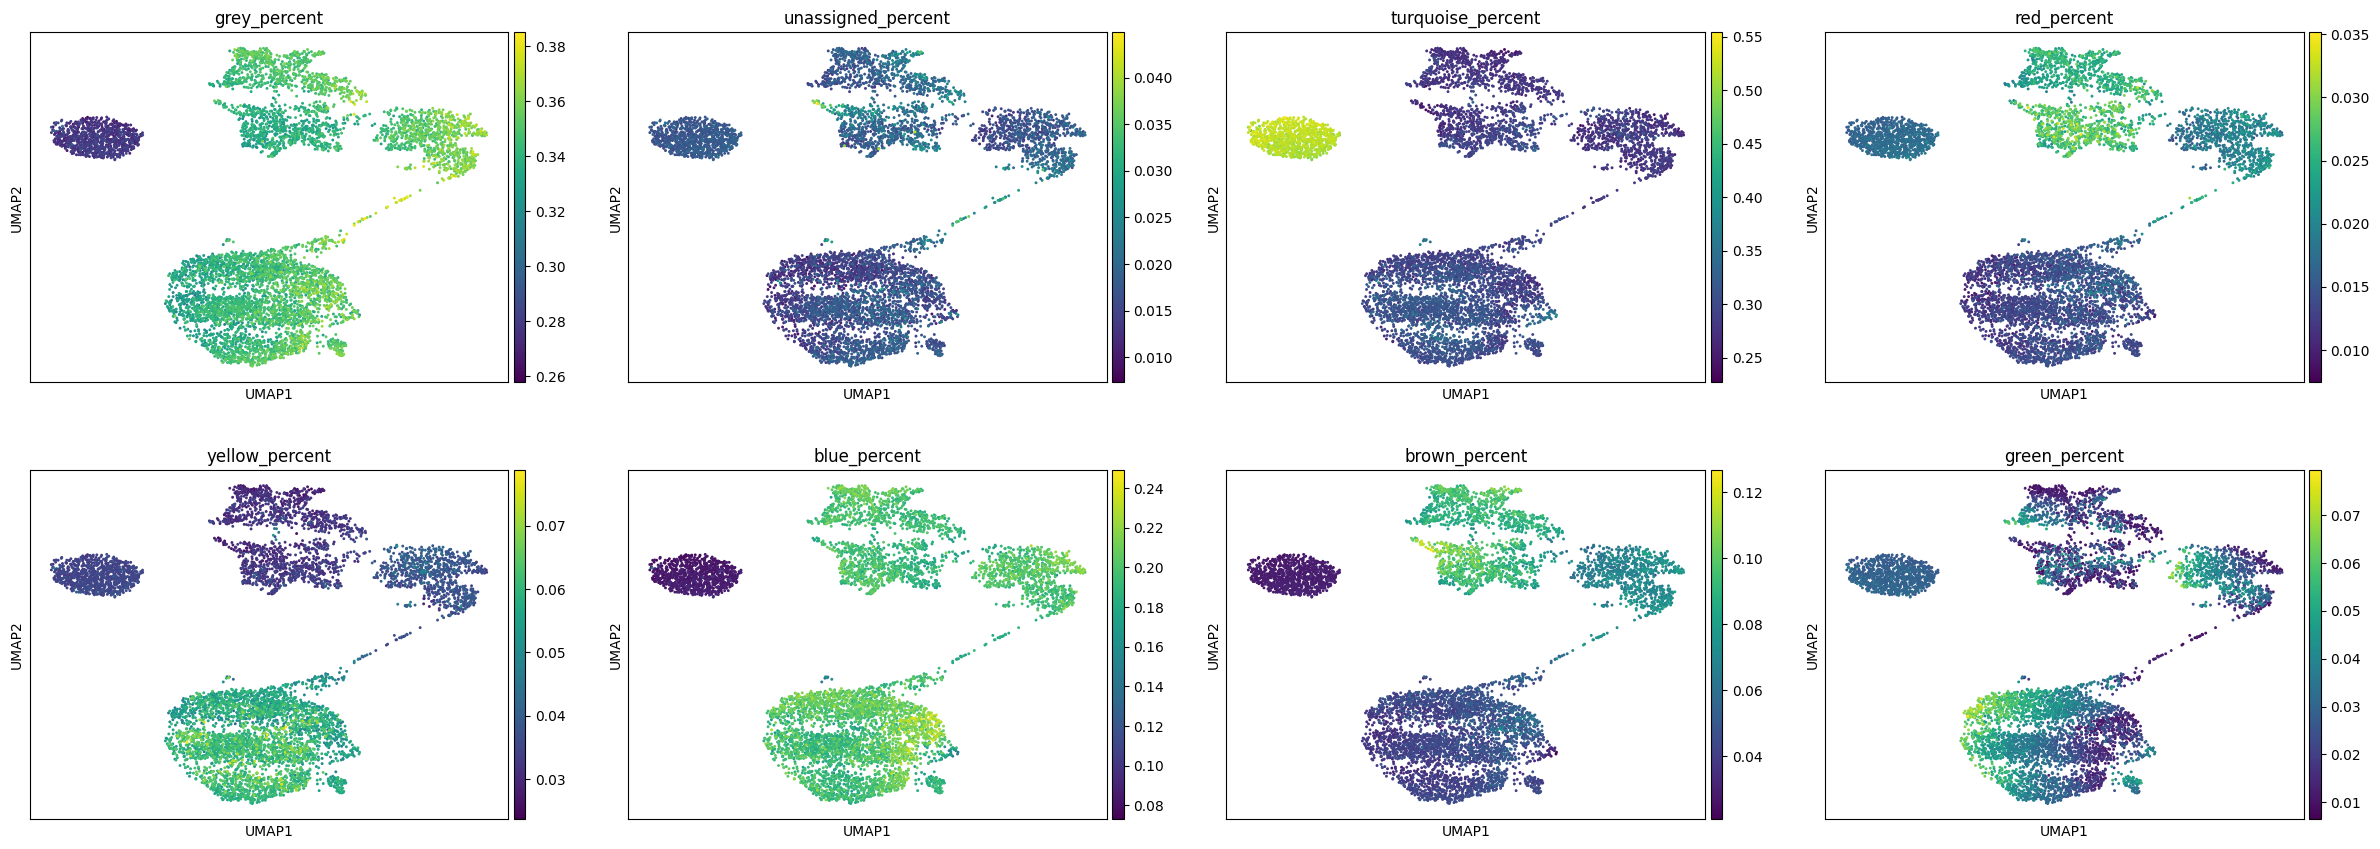

In [19]:
sc.pl.umap(adata, color=[f'{value}_percent' for value in adata.var['hdWGCNA_module'].unique()], ncols=4)

In [20]:
for value in adata.var['hdWGCNA_module'].unique():
    result = sc.metrics.morans_i(adata, vals=adata.obs[f"{value}_percent"])
    print(f"hdWGCNA module {value} has Moran's I of {result:.2f}")

hdWGCNA module grey has Moran's I of 0.99
hdWGCNA module unassigned has Moran's I of 0.56
hdWGCNA module turquoise has Moran's I of 1.04
hdWGCNA module red has Moran's I of 0.91
hdWGCNA module yellow has Moran's I of 0.94
hdWGCNA module blue has Moran's I of 1.01
hdWGCNA module brown has Moran's I of 0.96
hdWGCNA module green has Moran's I of 0.83


# Comparing hdWGCNA and GmGM clusters numerically.

GO term selection:

## Nervous System Development

Since our dataset consists of neural progenitor cells, it's natural to consider nervous system development GO terms.  We consider the following GO terms:

* Nervous system development (GO:0007399)
* All that either `regulates`, `positively_regulates`, or `negatively regulates` GO:0007399 (GO:0051961, GO:0051960, GO:0051962)
* The `is_a` and `part_of` children of all mentioned above (implicit)

Final list: GO:0007399, GO:0051961, GO:0051960, GO:0051962

## DNA Replication

This is one of the fundamental processes of cells.

* DNA replication (GO:0006260)
* All that either `regulates`, `positively_regulates`, or `negatively regulates` GO:0006260 (GO:0008156, GO:0045740, GO:0006275)
* The `is_a` and `part_of` children of all mentioned above (implicit)

Final list:  GO:0006260, GO:0008156, GO:0045740, GO:0006275

## Cell Cycle

This is one of the fundamental processes of cells.

* Cell cycle (GO:0007049)
* Regulators: (GO:0045786, GO:0045787, GO:0051726)
* Children

GO:0007049, GO:0045786, GO:0045787, GO:0051726

## Translation

One of the fundamental processes.

* Translation (GO:0006412)
* Regulators (GO:0032062, GO:0017148, GO:0140244, GO:0140245, GO:0140243, GO:0099578, GO:0099577)
* Regulators continued (GO:0032055, GO:0043557, GO:0043555, GO:0045727, GO:1902010, GO:0006417)
* Regulators continued (GO:0032061, GO:0032056, GO:0099547, GO:0036490, GO:0036493, GO:0043556, GO:0032939)
* Children

GO:0006412, GO:0032062, GO:0017148, GO:0140244, GO:0140245, GO:0140243, GO:0099578, GO:0099577, GO:0032055, GO:0043557, GO:0043555, GO:0045727, GO:1902010, GO:0006417, GO:0032061, GO:0032056, GO:0099547, GO:0036490, GO:0036493, GO:0043556, GO:0032939

## Splicing

Fundamental.

* RNA Splicing (GO:0008380)
* Regulators (GO:0033119, GO:0033120, GO:0042484)

GO:0008380, GO:0033119, GO:0033120, GO:0042484

## Synapse

Fundamental neuron part

* synapse (GO:0045202)
* `occurs_in` (GO:0140241, GO:0099574, GO:0140243)

GO:0045202, GO:0140241, GO:0099574, GO:0140243

## Synapse organization

GO:0050808, GO:1905809, GO:0050807

## Dendrite

Fundamental.

* dendrite (GO:0030425)
* `occurs_in`: NONE

## Dendrite development

GO:0016358, GO:0050773, GO:2000171, GO:1900006

## Axon

Fundamental.

* axon (GO:0030424)
* `occurs_in`: NONE

## Axon development

GO:0061564

## Myelin Sheath

Fundamental.

* myelin sheath (GO:0043209)
* `occurs_in`: (GO:0019911)

GO:0043209, GO:0019911

## Myelination

Fundamental.

* myelination (GO:0042552)
* regulators (GO:0031642, GO:0031641, GO:0031643)

GO:0042552, GO:0031642, GO:0031641, GO:0031643

In [21]:
adata

AnnData object with n_obs × n_vars = 6876 × 29324
    obs: 'source', 'm114_mean', 'm114_percent', 'm37_mean', 'm37_percent', 'm95_mean', 'm95_percent', 'm54_mean', 'm54_percent', 'm12_mean', 'm12_percent', 'm93_mean', 'm93_percent', 'm4_mean', 'm4_percent', 'm15_mean', 'm15_percent', 'm52_mean', 'm52_percent', 'm22_mean', 'm22_percent', 'm57_mean', 'm57_percent', 'm17_mean', 'm17_percent', 'm101_mean', 'm101_percent', 'm70_mean', 'm70_percent', 'm48_mean', 'm48_percent', 'm6_mean', 'm6_percent', 'm79_mean', 'm79_percent', 'm50_mean', 'm50_percent', 'm38_mean', 'm38_percent', 'm108_mean', 'm108_percent', 'm47_mean', 'm47_percent', 'm40_mean', 'm40_percent', 'm82_mean', 'm82_percent', 'm92_mean', 'm92_percent', 'm74_mean', 'm74_percent', 'm3_mean', 'm3_percent', 'm58_mean', 'm58_percent', 'm111_mean', 'm111_percent', 'm89_mean', 'm89_percent', 'm0_mean', 'm0_percent', 'm1_mean', 'm1_percent', 'm30_mean', 'm30_percent', 'm10_mean', 'm10_percent', 'm23_mean', 'm23_percent', 'm44_mean', 'm4

In [22]:
dataset = Dataset(name='hsapiens_gene_ensembl', host='http://www.ensembl.org')

df = dataset.query(
    attributes=[
        'external_gene_name',
        'go_id',
        'name_1006',
        "ensembl_gene_id"
    ],
    filters={
        'link_go_closure': ['GO:0003700', 'GO:0140110', 'GO:0000981']
    }
)


df = df.dropna().drop_duplicates()
adata.var["is_tf"] = adata.var["external_gene_name"].isin(df["Gene name"])
adata.var["is_tf"].value_counts()

is_tf
False    28192
True      1132
Name: count, dtype: int64

In [23]:
dataset = Dataset(name='hsapiens_gene_ensembl', host='http://www.ensembl.org')

df = dataset.query(
    attributes=[
        'external_gene_name',
        'go_id',
        'name_1006',
        "ensembl_gene_id"
    ],
    filters={
        'link_go_closure': ['GO:0007399', 'GO:0051961', 'GO:0051960', 'GO:0051962']
    }
)


df = df.dropna().drop_duplicates()
adata.var["is_neuro"] = adata.var["external_gene_name"].isin(df["Gene name"])
adata.var["is_neuro"].value_counts()

is_neuro
False    28709
True       615
Name: count, dtype: int64

In [24]:
dataset = Dataset(name='hsapiens_gene_ensembl', host='http://www.ensembl.org')

df = dataset.query(
    attributes=[
        'external_gene_name',
        'go_id',
        'name_1006',
        "ensembl_gene_id"
    ],
    filters={
        'link_go_closure': [
            'GO:0006412', 'GO:0032062', 'GO:0017148', 'GO:0140244', 'GO:0140245',
            'GO:0140243', 'GO:0099578', 'GO:0099577', 'GO:0032055', 'GO:0043557',
            'GO:0043555', 'GO:0045727', 'GO:1902010', 'GO:0006417', 'GO:0032061',
            'GO:0032056', 'GO:0099547', 'GO:0036490', 'GO:0036493', 'GO:0043556',
            'GO:0032939'
        ]
    }
)


df = df.dropna().drop_duplicates()
adata.var["translation"] = adata.var["external_gene_name"].isin(df["Gene name"])
adata.var["translation"].value_counts()

translation
False    28784
True       540
Name: count, dtype: int64

In [25]:
dataset = Dataset(name='hsapiens_gene_ensembl', host='http://www.ensembl.org')

df = dataset.query(
    attributes=[
        'external_gene_name',
        'go_id',
        'name_1006',
        "ensembl_gene_id"
    ],
    filters={
        'link_go_closure': ['GO:0007049', 'GO:0045786', 'GO:0045787', 'GO:0051726']
    }
)


df = df.dropna().drop_duplicates()
adata.var["cell_cycle"] = adata.var["external_gene_name"].isin(df["Gene name"])
adata.var["cell_cycle"].value_counts()

cell_cycle
False    28998
True       326
Name: count, dtype: int64

In [26]:
dataset = Dataset(name='hsapiens_gene_ensembl', host='http://www.ensembl.org')

df = dataset.query(
    attributes=[
        'external_gene_name',
        'go_id',
        'name_1006',
        "ensembl_gene_id"
    ],
    filters={
        'link_go_closure': ['GO:0006260', 'GO:0008156', 'GO:0045740', 'GO:0006275']
    }
)


df = df.dropna().drop_duplicates()
adata.var["dna_rep"] = adata.var["external_gene_name"].isin(df["Gene name"])
adata.var["dna_rep"].value_counts()

dna_rep
False    29131
True       193
Name: count, dtype: int64

In [27]:
dataset = Dataset(name='hsapiens_gene_ensembl', host='http://www.ensembl.org')

df = dataset.query(
    attributes=[
        'external_gene_name',
        'go_id',
        'name_1006',
        "ensembl_gene_id"
    ],
    filters={
        'link_go_closure': ['GO:0008380', 'GO:0033119', 'GO:0033120', 'GO:0042484']
    }
)


df = df.dropna().drop_duplicates()
adata.var["splicing"] = adata.var["external_gene_name"].isin(df["Gene name"])
adata.var["splicing"].value_counts()

splicing
False    29003
True       321
Name: count, dtype: int64

In [28]:
dataset = Dataset(name='hsapiens_gene_ensembl', host='http://www.ensembl.org')

df = dataset.query(
    attributes=[
        'external_gene_name',
        'go_id',
        'name_1006',
        "ensembl_gene_id"
    ],
    filters={
        'link_go_closure': ['GO:0045202', 'GO:0140241', 'GO:0099574', 'GO:0140243']
    }
)


df = df.dropna().drop_duplicates()
adata.var["synapse"] = adata.var["external_gene_name"].isin(df["Gene name"])
adata.var["synapse"].value_counts()

synapse
False    28378
True       946
Name: count, dtype: int64

In [29]:
dataset = Dataset(name='hsapiens_gene_ensembl', host='http://www.ensembl.org')

df = dataset.query(
    attributes=[
        'external_gene_name',
        'go_id',
        'name_1006',
        "ensembl_gene_id"
    ],
    filters={
        'link_go_closure': ["GO:0050808", "GO:1905809", "GO:0050807"]
    }
)


df = df.dropna().drop_duplicates()
adata.var["synapse_organization"] = adata.var["external_gene_name"].isin(df["Gene name"])
adata.var["synapse_organization"].value_counts()

synapse_organization
False    29225
True        99
Name: count, dtype: int64

In [30]:
adata.var["all_synapse"] = adata.var["synapse_organization"] | adata.var["synapse"]
adata.var["all_synapse"].value_counts()

all_synapse
False    28337
True       987
Name: count, dtype: int64

In [31]:
dataset = Dataset(name='hsapiens_gene_ensembl', host='http://www.ensembl.org')

df = dataset.query(
    attributes=[
        'external_gene_name',
        'go_id',
        'name_1006',
        "ensembl_gene_id"
    ],
    filters={
        'link_go_closure': ['GO:0030425']
    }
)


df = df.dropna().drop_duplicates()
adata.var["dendrite"] = adata.var["external_gene_name"].isin(df["Gene name"])
adata.var["dendrite"].value_counts()

dendrite
False    28853
True       471
Name: count, dtype: int64

In [32]:
dataset = Dataset(name='hsapiens_gene_ensembl', host='http://www.ensembl.org')

df = dataset.query(
    attributes=[
        'external_gene_name',
        'go_id',
        'name_1006',
        "ensembl_gene_id"
    ],
    filters={
        'link_go_closure': ['GO:0016358', 'GO:0050773', 'GO:2000171', 'GO:1900006']
    }
)


df = df.dropna().drop_duplicates()
adata.var["dendrite_development"] = adata.var["external_gene_name"].isin(df["Gene name"])
adata.var["dendrite_development"].value_counts()

dendrite_development
False    29245
True        79
Name: count, dtype: int64

In [33]:
adata.var["all_dendrite"] = adata.var["dendrite_development"] | adata.var["dendrite"]
adata.var["all_dendrite"].value_counts()

all_dendrite
False    28797
True       527
Name: count, dtype: int64

In [34]:
dataset = Dataset(name='hsapiens_gene_ensembl', host='http://www.ensembl.org')

df = dataset.query(
    attributes=[
        'external_gene_name',
        'go_id',
        'name_1006',
        "ensembl_gene_id"
    ],
    filters={
        'link_go_closure': ['GO:0030424']
    }
)


df = df.dropna().drop_duplicates()
adata.var["axon"] = adata.var["external_gene_name"].isin(df["Gene name"])
adata.var["axon"].value_counts()

axon
False    28910
True       414
Name: count, dtype: int64

In [35]:
dataset = Dataset(name='hsapiens_gene_ensembl', host='http://www.ensembl.org')

df = dataset.query(
    attributes=[
        'external_gene_name',
        'go_id',
        'name_1006',
        "ensembl_gene_id"
    ],
    filters={
        'link_go_closure': ['GO:0061564']
    }
)


df = df.dropna().drop_duplicates()
adata.var["axon_development"] = adata.var["external_gene_name"].isin(df["Gene name"])
adata.var["axon_development"].value_counts()

axon_development
False    29288
True        36
Name: count, dtype: int64

In [36]:
adata.var["all_axon"] = adata.var["axon_development"] | adata.var["axon"]
adata.var["all_axon"].value_counts()

all_axon
False    28884
True       440
Name: count, dtype: int64

In [37]:
dataset = Dataset(name='hsapiens_gene_ensembl', host='http://www.ensembl.org')

df = dataset.query(
    attributes=[
        'external_gene_name',
        'go_id',
        'name_1006',
        "ensembl_gene_id"
    ],
    filters={
        'link_go_closure': ['GO:0043209', 'GO:0019911']
    }
)


df = df.dropna().drop_duplicates()
adata.var["sheath"] = adata.var["external_gene_name"].isin(df["Gene name"])
adata.var["sheath"].value_counts()

sheath
False    29289
True        35
Name: count, dtype: int64

In [38]:
dataset = Dataset(name='hsapiens_gene_ensembl', host='http://www.ensembl.org')

df = dataset.query(
    attributes=[
        'external_gene_name',
        'go_id',
        'name_1006',
        "ensembl_gene_id"
    ],
    filters={
        'link_go_closure': ['GO:0042552', 'GO:0031642', 'GO:0031641', 'GO:0031643']
    }
)


df = df.dropna().drop_duplicates()
adata.var["myelination"] = adata.var["external_gene_name"].isin(df["Gene name"])
adata.var["myelination"].value_counts()

myelination
False    29212
True       112
Name: count, dtype: int64

In [39]:
adata.var["all_myelin"] = adata.var["sheath"] | adata.var["myelination"]
adata.var["all_myelin"].value_counts()

all_myelin
False    29193
True       131
Name: count, dtype: int64

In [40]:
adata

AnnData object with n_obs × n_vars = 6876 × 29324
    obs: 'source', 'm114_mean', 'm114_percent', 'm37_mean', 'm37_percent', 'm95_mean', 'm95_percent', 'm54_mean', 'm54_percent', 'm12_mean', 'm12_percent', 'm93_mean', 'm93_percent', 'm4_mean', 'm4_percent', 'm15_mean', 'm15_percent', 'm52_mean', 'm52_percent', 'm22_mean', 'm22_percent', 'm57_mean', 'm57_percent', 'm17_mean', 'm17_percent', 'm101_mean', 'm101_percent', 'm70_mean', 'm70_percent', 'm48_mean', 'm48_percent', 'm6_mean', 'm6_percent', 'm79_mean', 'm79_percent', 'm50_mean', 'm50_percent', 'm38_mean', 'm38_percent', 'm108_mean', 'm108_percent', 'm47_mean', 'm47_percent', 'm40_mean', 'm40_percent', 'm82_mean', 'm82_percent', 'm92_mean', 'm92_percent', 'm74_mean', 'm74_percent', 'm3_mean', 'm3_percent', 'm58_mean', 'm58_percent', 'm111_mean', 'm111_percent', 'm89_mean', 'm89_percent', 'm0_mean', 'm0_percent', 'm1_mean', 'm1_percent', 'm30_mean', 'm30_percent', 'm10_mean', 'm10_percent', 'm23_mean', 'm23_percent', 'm44_mean', 'm4

In [41]:
bdata = adata.transpose()
sc.tl.leiden(bdata, key_added = 'leiden_coarse_gmgm', adjacency=adata.varp["var_gmgm_connectivities"], resolution=0.29)
adata.var["leiden_coarse_gmgm"] = bdata.obs["leiden_coarse_gmgm"]
bdata.obs["leiden_coarse_gmgm"].value_counts()

leiden_coarse_gmgm
0    12907
1     8945
2     2928
3     1739
4      830
5      735
6      691
7      289
8      260
Name: count, dtype: int64

In [42]:
bdata.obs["leiden_gmgm"].value_counts()

leiden_gmgm
0      9047
1      1756
2       600
3       433
4       319
       ... 
114      78
115      74
116      63
117      48
118      37
Name: count, Length: 119, dtype: int64

In [43]:
hd_names = hdWGCNA_names["name"].to_numpy()

# Find positions of those names in bdata.obs_names
bdata_pos = bdata.obs_names.get_indexer(hd_names)

# Reorder bdata to exactly match hdWGCNA_network
bdata_hd = bdata[bdata_pos].copy()

# Final sanity check (optional but recommended)
assert np.all(bdata_hd.obs_names == hd_names)

# Run Leiden using the precomputed adjacency
sc.tl.leiden(
    bdata_hd,
    key_added="fine_hdWGCNA",
    resolution=3.89155, # has to be this precise to get 119 clusters!
    adjacency=hdWGCNA_network
)

# Map labels back to the full AnnData
bdata.obs["fine_hdWGCNA"] = "unassigned"
bdata.obs.loc[bdata_hd.obs_names, "fine_hdWGCNA"] = bdata_hd.obs["fine_hdWGCNA"]
adata.var["fine_hdWGCNA"] = bdata.obs["fine_hdWGCNA"]

bdata_hd.obs["fine_hdWGCNA"].value_counts()

fine_hdWGCNA
0      2998
1      1903
2      1699
3      1558
4      1474
       ... 
50        1
49        1
48        1
47        1
118       1
Name: count, Length: 119, dtype: int64

/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/balanced_clustering/ami.py:102: RuntimeWarning: divide by zero encountered in log
  emi = expected_mutual_information(contingency, n_samples)
/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/balanced_clustering/ami.py:102: RuntimeWarning: divide by zero encountered in log
  emi = expected_mutual_information(contingency, n_samples)
/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/balanced_clustering/ami.py:102: RuntimeWarning: divide by zero encountered in log
  emi = expected_mutual_information(contingency, n_samples)
/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/balanced_clustering/ami.py:102: RuntimeWarning: divide by zero encountered in log
  emi = expected_mutual_information(contingency, n_samples)
/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/balanced_clustering/ami.py:102: RuntimeWarning: divide by zero

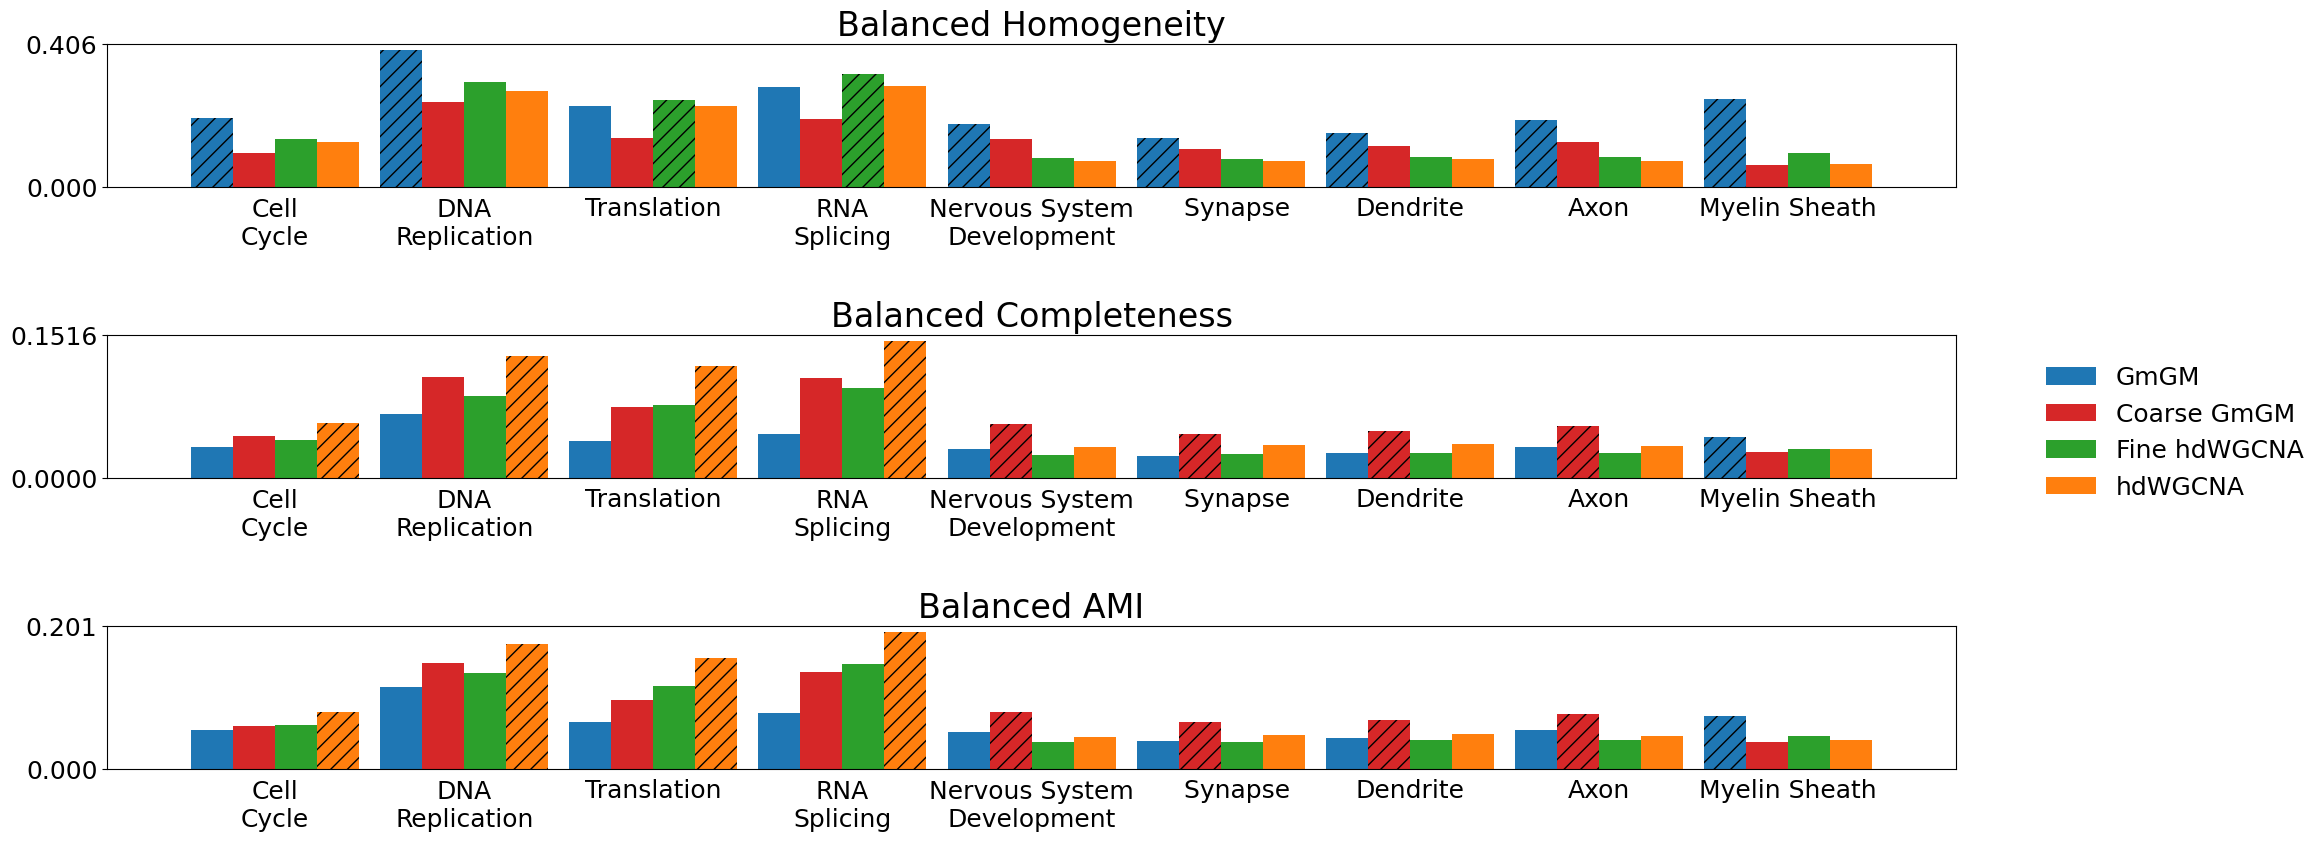

In [53]:
scores = [balanced_homogeneity, balanced_completeness, balanced_adjusted_mutual_info]
scenarios = [
    "cell_cycle", "dna_rep", "translation", "splicing",
    "is_neuro", "all_synapse", "all_dendrite", "all_axon", "all_myelin"
]
methods = ["leiden_gmgm", "leiden_coarse_gmgm", "fine_hdWGCNA", "hdWGCNA_module"]
method_colors = ["tab:blue", "tab:red", "tab:green", "tab:orange"]
method_labels = ["GmGM", "Coarse GmGM", "Fine hdWGCNA", "hdWGCNA"]
score_names = ["Balanced Homogeneity", "Balanced Completeness", "Balanced AMI"]
scenario_names = [
    "Cell\nCycle", "DNA\nReplication", "Translation", "RNA\nSplicing",
    "Nervous System\nDevelopment", "    Synapse", "Dendrite", "Axon", "Myelin Sheath"
]

mat = np.zeros((len(scores), len(scenarios), len(methods)))
for i, score in enumerate(scores):
    for j, scenario in enumerate(scenarios):
        for k, method in enumerate(methods):
            mat[i, j, k] = score(adata.var[scenario], adata.var[method])

fig, axs = plt.subplots(figsize=(20, 9), nrows=len(scores), ncols = 1)
axs = axs.flatten()

legend_handles = [
    Patch(facecolor=method_colors[k], label=method_labels[k])
    for k in range(len(methods))
]

for i, (ax, score_name) in enumerate(zip(axs, score_names)):
    ax.set_title(score_name)
    ax.set_xticks([])
    for j in range(len(scenarios)):
        for k in range(len(methods)):
            labels = {}
            if mat[i, j, :].argmax() == k:
                labels |= {"hatch": "//"}
            ax.bar(k + (len(methods) + 0.5) * j, mat[i, j, k], 1, color=method_colors[k], **labels)
            if k == 0:
                # Draw axis group label
                trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
                ax.text(
                    (len(methods) + 0.5) * j + (len(methods)-1)/2, -0.2 - 0.2 * scenario_names[j].count('\n'),
                    scenario_names[j],
                    transform=trans,
                    ha='center'
                )
    #ax.legend(handles=legend_handles)
    ymin, ymax = ax.get_ylim()
    ax.set_yticks([ymin, ymax])

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18
})

fig.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

fig.tight_layout()

Note: (https://jmlr.csail.mit.edu/papers/volume17/15-627/15-627) AMI > ARI when the ground truth clustering is imbalanced.  This is the case here, where only <5% of genes are in the True cluster in each category.

Uisng balanced clustering methods (https://www.nature.com/articles/s41587-023-02097-9) as our calculated clusters in all metrics are highly imbalanced (largest cluster being much larger than smallest).

## Modularity

Modularity measures how good a partition of a graph is purely based on the underlying graph.  It is higher if edges between nodes tend to be between nodes in the same cluster.

In [45]:
gmgm_graph = ig.Graph.Weighted_Adjacency(adata.varp['var_gmgm_connectivities'])
hdWGCNA_graph = ig.Graph.Weighted_Adjacency(hdWGCNA_network)

# Both adata.var_names and hdWGCNA_names are in alphabetic order
hdWGCNA_indexer = adata.var_names.isin(hdWGCNA_names["name"])

In [46]:
fine_gmgm_community = adata.var['leiden_gmgm'].astype(int)
gmgm_graph.modularity(fine_gmgm_community)

/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/igraph/community.py:506: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return GraphBase.modularity(self, membership, weights, resolution, directed)


0.5693879154124738

In [47]:
coarse_gmgm_community = adata.var['leiden_coarse_gmgm'].astype(int)
gmgm_graph.modularity(coarse_gmgm_community)

/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/igraph/community.py:506: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return GraphBase.modularity(self, membership, weights, resolution, directed)


0.6007550950582901

In [48]:
fine_hdwgcna_community = adata[:, hdWGCNA_indexer].var['fine_hdWGCNA'].astype('category').cat.codes
hdWGCNA_graph.modularity(fine_hdwgcna_community)

/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/igraph/community.py:506: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return GraphBase.modularity(self, membership, weights, resolution, directed)


0.3474801994087777

In [49]:
coarse_hdwgcna_community = adata[:, hdWGCNA_indexer].var['hdWGCNA_module'].astype('category').cat.codes
hdWGCNA_graph.modularity(coarse_hdwgcna_community)

/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/igraph/community.py:506: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return GraphBase.modularity(self, membership, weights, resolution, directed)


0.2197895599617967

In [50]:
hdWGCNA_graph.vs['coarse_hdwgcna'] = coarse_hdwgcna_community
hdWGCNA_graph.vs['fine_hdwgcna'] = fine_hdwgcna_community
gmgm_graph.vs['coarse_hdwgcna'] = coarse_gmgm_community
gmgm_graph.vs['fine_hdwgcna'] = fine_hdwgcna_community

/var/folders/k0/qy74mdx10qs493700g929k5h0000gn/T/ipykernel_32886/1622774113.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hdWGCNA_graph.vs['coarse_hdwgcna'] = coarse_hdwgcna_community
/var/folders/k0/qy74mdx10qs493700g929k5h0000gn/T/ipykernel_32886/1622774113.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hdWGCNA_graph.vs['fine_hdwgcna'] = fine_hdwgcna_community
/var/folders/k0/qy74mdx10qs493700g929k5h0000gn/T/ipykernel_32886/1622774113.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFr

In [51]:
# hdWGCNA_graph.write_graphml('./results/igraphs/hdWGCNA.graphml')
# gmgm_graph.write_graphml('./results/igraphs/GmGM.graphml')